In [40]:
import numpy as np
import math
import matplotlib.pyplot as plt
from multiprocessing import Process
from multiprocessing import Pool
from scipy.stats import lognorm
import time as sys_time
from aquarel import load_theme

%matplotlib inline

In [16]:
def ramping_cell(
    start_time: float,
    h: float,
    end_time: float,
    stimulus: list | np.ndarray,
    time_constant: float) -> tuple[list, np.ndarray]: 
    '''
    Simulate one ramping cell activity as an RC circuit with 
    time_constant and stimulus for some start_time and end_time
    with step size h

    Args:
        start_time: when to start simulation 
        h: step size
        end_time: when to end simulation
        stimulus: stimulus to ramping cell
        time_constant: time constant of ramping cell

    Returns:
        The simulated neural activity and generated linear time


    Raises:
        None
    '''
    stim = stimulus
    s = time_constant
    time = np.linspace(start_time, end_time, int((end_time-start_time)/h + 1))
    neural_activity = [0]
    
    for i in range(len(time)-1):
        update = neural_activity[i] + h * (-s * neural_activity[i] + stim[i])
        neural_activity.append(update)

    return neural_activity, time 

In [17]:
def parallel_ramping_cell(start_time: float,
                          h: float,
                          end_time: float,
                          stimulus: np.ndarray,
                          time_constant: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    '''
    Simulate one ramping cell activity as an RC circuit with an array
    of time_constants and stimulus for some start_time and end_time
    with step size h

    Args:
        start_time: when to start simulation 
        h: step size
        end_time: when to end simulation
        stimulus: stimulus to ramping cell
        time_constant: time constant of ramping cell

    Returns:
        The simulated neural activity and generated linear time


    Raises:
        None
    '''
    stim = stimulus
    s = time_constant
    time = np.linspace(start_time, end_time, int((end_time-start_time)/h) + 1)

    neural_activity = np.zeros((len(time_constant), len(time)))
    
    for i in range(len(time) - 1):
        update = neural_activity[:,i] + (h * (-s * neural_activity[:,i] + stim[i]))
        neural_activity[:,i+1] = update

    return neural_activity, time

In [18]:
def time_constant_sample(seed=20080204, size=1, a=1.0, b=math.e):
    '''
    Sample the time constants based on power-law 1/x based on seed.
    
    Args:
    - seed (int): The random seed for reproducibility.
    - size (int or tuple): The number of samples to generate.
    - a (float): The lower bound of the distribution (must be > 0).
    - b (float): The upper bound of the distribution.
    
    Returns:
    - float or numpy.ndarray: The sampled time constant(s).
    '''
    if a <= 0 or b <= a:
        raise ValueError("Bounds must satisfy 0 < a < b")
        
    # Set the random seed
    np.random.seed(seed)
    
    # 1. Sample uniformly from [0, 1)
    u = np.random.uniform(0, 1, size)
    
    # 2. Apply the inverse CDF for the 1/x distribution
    samples = a * np.power(b / a, u)
    
    # Return a scalar if size is 1 to keep things clean, otherwise return the array
    return samples[0] if size == 1 else samples

## parallel ramping cells
Two approaches tried:
- parallel computing, lots of time spent in data pipeline without actual computation
- vectorization, faster

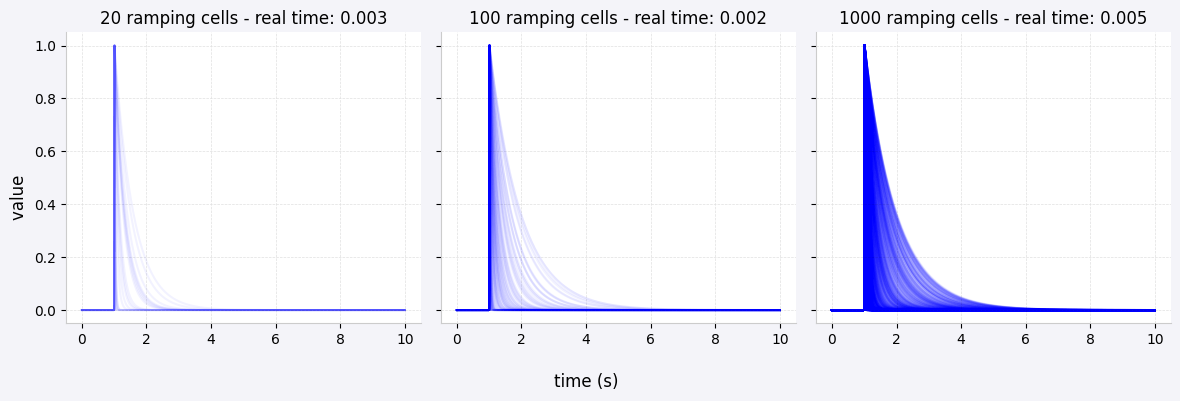

In [19]:
# Takes an insane amount of time to run
sample_size = 10000
sample_array = [20, 100, 1000]
lower_bound = 1
upper_bound = 100
start_time = 0
end_time = 10
h = 0.01
datapoints = int((end_time - start_time)/h)

# create two stimulus types
# stimulus1: short step
# stimulus2: impulse
stimulus1 = np.zeros(datapoints)
stimulus1[int(datapoints*0.1):int(datapoints*0.3)] = 1

stimulus2 = np.zeros(datapoints)
stimulus2[int(datapoints*0.1)] = 1/h

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex=True, sharey=True, figsize=(12,4))

# 1. Set the outer figure background color
fig.patch.set_facecolor('#f4f4f9') # A very soft, warm off-white

# 2. Loop through every subplot to apply the styling
for axis in ax:
    # Set the inner plotting area background color
    axis.set_facecolor('#ffffff') 
    
    # Soften the grid lines
    axis.grid(True, color='#e0e0e0', linestyle='--', linewidth=0.5)
    
    # Remove the top and right borders (spines) for a clean look
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_color('#cccccc')
    axis.spines['bottom'].set_color('#cccccc')

for i in range(len(sample_array)):
    xi_sample = time_constant_sample(size=sample_array[i], a = lower_bound, b = upper_bound)
    start_timer = sys_time.perf_counter()
    ramp_cells, time = parallel_ramping_cell(start_time, h, end_time, stimulus2, xi_sample)
    finish_timer = sys_time.perf_counter()

    # for j in range(sample_array[i]):
    #     ax[i].plot(time, ramp_cells[j,:])
    ax[i].plot(time, ramp_cells.T, color='blue', alpha = 0.05)
    ax[i].set_title(f'{sample_array[i]} ramping cells - real time: {np.round(finish_timer - start_timer, 3)}')

fig.supxlabel('time (s)')
fig.supylabel('value ')
plt.tight_layout()
plt.savefig('Laplace_operator.png')
plt.show()

## An illustration of ramping cells performing real-valued Laplace transform

<Figure size 640x480 with 0 Axes>

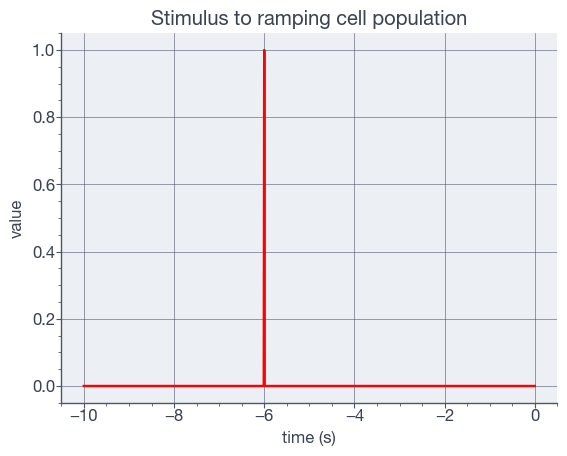

<Figure size 640x480 with 0 Axes>

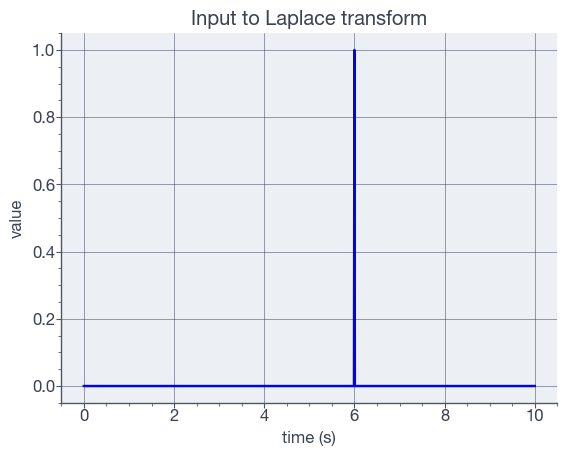

In [52]:
tau = 0 # current time
sample_size = 10000
sample_array = [20, 500, 10000]
lower_bound = 1
upper_bound = 100
start_time = 0
end_time = 10
h = 0.01
datapoints = int((end_time - start_time)/h) + 1
time = np.linspace(start_time, end_time, datapoints)

# simulate a single spike
stimulus1 = np.zeros(datapoints)
stimulus1[int((datapoints - 1) * 0.6)] = 1

# simulate a short pulse
stimulus2 = np.zeros(datapoints)
stimulus2[int((datapoints - 1) * 0.2):int((datapoints - 1) * 0.4)] = 1

# f(t) as our input
# simulate a spike in the past
# stimulus1_past[400], past_time[400] - (np.float64(1.0), np.float64(-6.0))
input_display = False
past_time = np.linspace(-end_time, -start_time, datapoints)
stimulus1_past = np.zeros(datapoints)
stimulus1_past[int((datapoints - 1) * 0.4)] = 1

# f(-t) as our input to the Laplace transform 
stimulus1_invert = stimulus1_past[::-1]

# Visualization
if input_display:
    with load_theme("arctic_light"):
        plt.figure()
        plt.plot(past_time, stimulus1_past, 'red')
        plt.xlabel('time (s)')
        plt.ylabel('value')
        plt.title('Stimulus to ramping cell population')
        plt.savefig('Stim_to_pop.png')
        plt.show()
    
        plt.figure()
        plt.plot(time, stimulus1_invert, 'blue')
        plt.xlabel('time (s)')
        plt.ylabel('value')
        plt.title('Input to Laplace transform')
        plt.savefig('Input_to_LT.png')
        plt.show()

In [ ]:
# # Takes an insane amount of time to run
# np.random.seed(20020408)
# sample_size = 100
# lower_bound = 1
# upper_bound = 100
# start_time = 0
# end_time = 4
# h = 0.01
# datapoints = int((end_time - start_time)/h)

# # create two stimulus types
# # stimulus1: short step
# # stimulus2: impulse
# stimulus1 = np.zeros(datapoints)
# stimulus1[int(datapoints*0.1):int(datapoints*0.3)] = 1

# stimulus2 = np.zeros(datapoints)
# stimulus2[int(datapoints*0.1)] = 1

# xi_sample = time_constant_sample(size=sample_size, a = lower_bound, b = upper_bound)

# # A set of identical stimulus gets fed into a population of ramping cells
# stimulus1_set = []
# for i in range(sample_size):
#     stimulus1_i = (start_time, h, end_time, stimulus1, xi_sample[i])
#     stimulus1_set.append(stimulus1_i)

# stimulus2_set = []
# for i in range(sample_size):
#     stimulus2_i = (start_time, h, end_time, stimulus2, xi_sample[i])
#     stimulus2_set.append(stimulus2_i)


# start_timer = sys_time.perf_counter()
# if __name__ == "__main__":
#     with Pool() as pool:
#         ramp, time = pool.starmap(ramping_cell, stimulus1_set)
# finish_timer = sys_time.perf_counter()
# print("Program finished in {} seconds".format(finish_timer - start_timer))

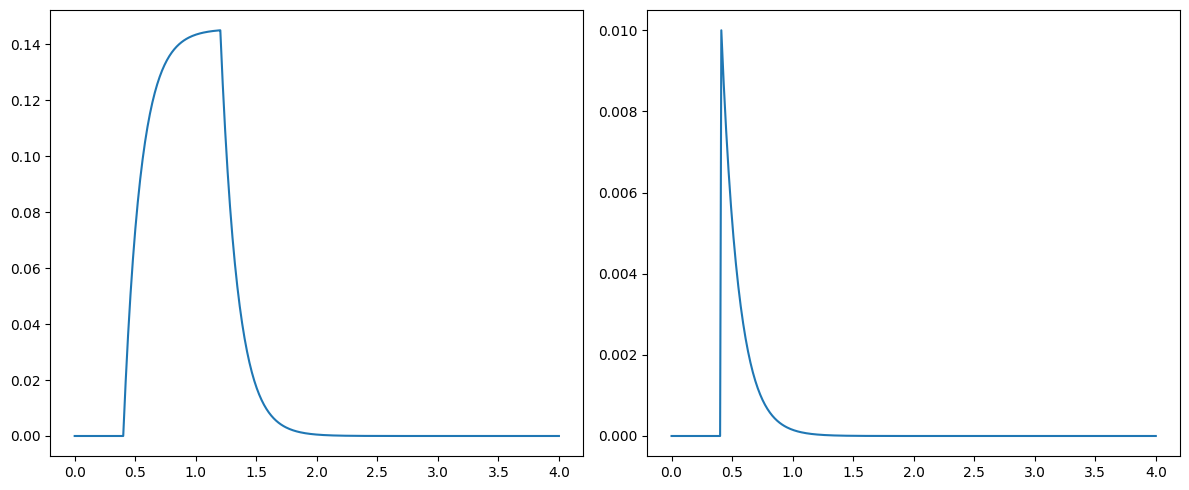

In [21]:
start_time = 0
end_time = 4
h = 0.01
datapoints = int((end_time - start_time)/h)
time_constant = time_constant_sample(seed=20080204, size=1, a=1.0, b=100)

stimulus1 = np.zeros(datapoints)
stimulus1[int(datapoints*0.1):int(datapoints*0.3)] = 1

stimulus2 = np.zeros(datapoints)
stimulus2[int(datapoints*0.1)] = 1
ramp1, time = ramping_cell(start_time, h, end_time, stimulus1, time_constant)
ramp2, time = ramping_cell(start_time, h, end_time, stimulus2, time_constant)

# --- 1. Standard Histogram ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# bins=50 divides the range [1, 100] into 50 equal-width chunks
plt.plot(time, ramp1)
# --- 2. Log-Binned Histogram (Better for 1/x data) ---
plt.subplot(1, 2, 2)
plt.plot(time, ramp2)

plt.tight_layout()
plt.show()


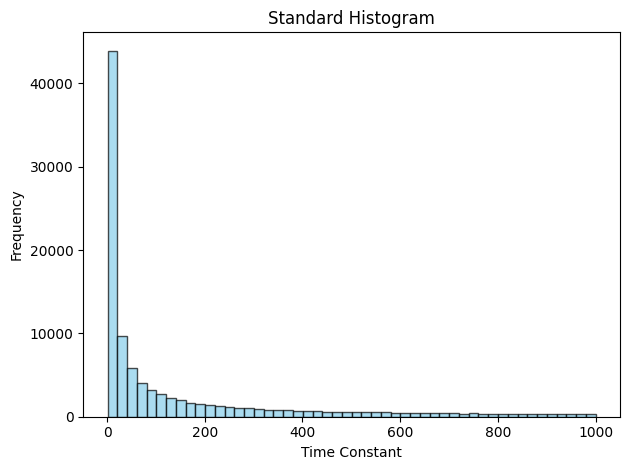

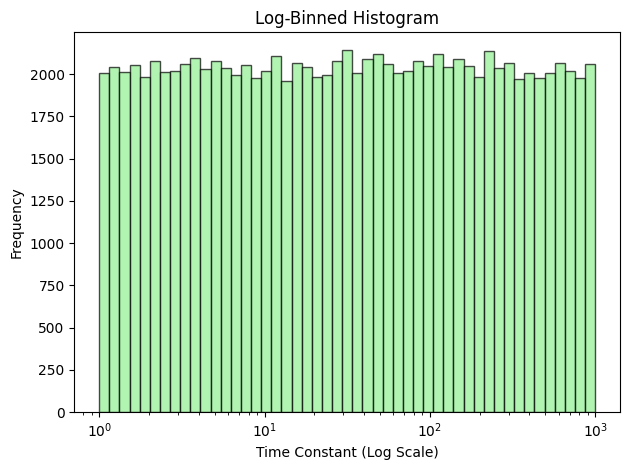

In [29]:
sample_size = 100000
lower_bound = 1
upper_bound = 1000

samples = time_constant_sample(size=sample_size, a = lower_bound, b = upper_bound)
# --- 1. Standard Histogram ---
plt.figure()
# bins=50 divides the range [1, 100] into 50 equal-width chunks
plt.hist(samples, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Standard Histogram')
plt.xlabel('Time Constant')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('standard_histo')

plt.figure()
# Create 50 bins that are evenly spaced on a logarithmic scale instead of a linear one
log_bins = np.logspace(np.log10(lower_bound), np.log10(upper_bound), 50)

plt.hist(samples, bins=log_bins, color='lightgreen', edgecolor='black', alpha=0.7)
plt.xscale('log') # Set the x-axis to a log scale so the bins look evenly spaced
plt.title('Log-Binned Histogram')
plt.xlabel('Time Constant (Log Scale)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('log_histo')